# Financial Fraud Detection - Complete Preprocessing Pipeline

This notebook combines comprehensive data exploration with systematic generation of preprocessing variants.

## Pipeline Overview

### Phase 1: Data Exploration 
1. **Dataset Loading** - Load fraud detection dataset from Hugging Face
2. **Initial Exploration** - Examine structure, types, statistics, missing values
3. **Outlier Analysis** - Detect and analyze outliers using IQR method with visualizations

### Phase 2: Feature Engineering & Variant Generation
Now that we have clean, explored, and balanced data, we proceed with:
1. **Feature engineering** (creating derived features)
2. **Data Splitting** - Create train/val/test 
3. **Systematic generation** of 43+ preprocessing variants

### Phase 3: Model Evaluation

1. **Train XGBoost** on all variants with consistent hyperparameters- Identify best preprocessing strategy for maximum fraud detection 
2. **Evaluate performance** using Recall as primary metric (fraud detection priority)

## Phase 1 : Data Exploration

### Step 0: import libraries and config 

In [1]:
import os, gc, json, warnings, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, OneSidedSelection, NeighbourhoodCleaningRule
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif, VarianceThreshold, RFE, SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA, TruncatedSVD, KernelPCA
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

try:
    import umap
    UMAP_AVAILABLE = True
except:
    UMAP_AVAILABLE = False

warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [2]:
# Configuration du pipeline
CONFIG = {
    'sample_size': 1_000_000,
    'test_size': 0.15,
    'val_size': 0.15,
    'n_features_to_select': 10,
    'correlation_threshold': 0.95,
    'n_components_pca': 8,
    'n_components_lda': 1,
    'n_components_svd': 8,
    'n_components_umap': 8,
    
    # Kernel PCA - TRÈS LOURD, désactivé par défaut
    'enable_kernel_pca': False,  # Mettre True si vous avez >16GB RAM
    'kernel_pca_sample_size': 5000,
    
    'output_dir': '../../data/data_variants/',
    'random_state': 42,
    'skip_existing': True,
}
os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"\nOutput directory: {CONFIG['output_dir']}")
if CONFIG['enable_kernel_pca']:
    print("Kernel PCA activé - cela peut prendre du temps")
else:
    print("ℹKernel PCA désactivé (trop lourd)")


Output directory: ../../data/data_variants/
ℹKernel PCA désactivé (trop lourd)


### Step 1: Dataset Loading

This section loads the "Cifer-Fraud-Detection-Dataset-AF" dataset from Hugging Face.
The dataset is intended for fraud detection tasks in financial transactions.

We use the `datasets` library to fetch the data, then convert it to a Pandas DataFrame
with proper data types for easier manipulation and analysis.

In [3]:
print("Chargement...")
df = load_dataset("CiferAI/Cifer-Fraud-Detection-Dataset-AF", split="train").to_pandas()
print(f"Original: {df.shape}")
if CONFIG['sample_size'] and CONFIG['sample_size'] < len(df):
    df = df.groupby('isFraud', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), CONFIG['sample_size']//2), random_state=42)
    ).reset_index(drop=True)
    print(f"Échantillon: {df.shape}")

Chargement...
Original: (21000000, 11)
Échantillon: (527470, 11)


### Step 2: Initial Data Exploration

We perform comprehensive exploratory data analysis to understand the dataset structure,
identify data quality issues, and prepare for preprocessing.

#### 2.1. Dataset Overview

Display the first rows to get a quick overview of the dataset's structure
and verify that the data loaded correctly.

In [4]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,75,TRANSFER,11586.93,C560918671,464.19,579.06,C1732080599,2101723.28,10001.11,0,0
1,197,CASH_OUT,476.91,C1150309179,141360.11,1817839.37,C2027771540,334001.65,0.42,0,0
2,257,PAYMENT,314.61,C176282288,87407.60,1902886.32,M1191991828,42087.70,0.00,0,0
3,84,TRANSFER,6955.42,C211581816,3043952.70,3272289.65,M920073170,663609.61,0.00,0,0
4,194,CASH_OUT,19571.12,C1517046261,144717.01,1396935.92,M1395047386,1257471.24,2087010.76,0,0


#### 2.2. Dataset Shape and Column Types

Understanding the number of transactions (rows) and features (columns),
along with their data types, helps identify:
- Numerical features (Int64, Float64) suitable for calculations
- Categorical features (string) suitable for encoding or analysis
- Target variable for fraud detection: 'isFraud'

In [5]:
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Column data types:")
display(df.dtypes.to_frame("Data Type"))

Dataset shape: 527,470 rows x 11 columns

Column data types:


,Data Type
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


#### 2.3. Descriptive Statistics

Summary statistics for all columns to understand:
- The distribution of numerical features (mean, min, max, std)
- The unique values and counts for categorical features
- Potential anomalies or unexpected ranges in the data

In [6]:
print("Descriptive statistics for all columns:")
display(df.describe(include="all").T)

Descriptive statistics for all columns:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,527470.0,NaN,NaN,NaN,238.954117,163.261626,1.0,112.0,205.0,333.0,743.0
type,527470,5,CASH_OUT,185479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,527470.0,NaN,NaN,NaN,179829.760218,253165.190677,0.0,18558.005,82408.35,238999.7875,3679459.27
nameOrig,527470,516228,C424804592,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,527470.0,NaN,NaN,NaN,1340200.579707,2575727.237314,0.01,10769.945,217318.72,1431253.8175,34802049.29
newbalanceOrig,527470.0,NaN,NaN,NaN,2085678.716363,3406542.651677,0.0,58901.5075,586522.075,2605290.77,34866573.02
nameDest,527470,443452,C798678484,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,527470.0,NaN,NaN,NaN,1932359.341371,2498494.376319,0.01,272568.7675,1008996.1,2622711.8025,40540836.03
newbalanceDest,527470.0,NaN,NaN,NaN,3744677.534965,10322115.412174,0.0,99.63,64710.02,2023448.3775,229612940.93
isFraud,527470.0,NaN,NaN,NaN,0.052079,0.222186,0.0,0.0,0.0,0.0,1.0


#### 2.4. Data Quality Checks

We check for missing values and duplicates to ensure data completeness and uniqueness.

In [7]:
missing_count = df.isna().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"Total missing values in the dataset: {missing_count}")
print(f"Total duplicated rows in the dataset: {duplicate_count}")

if missing_count == 0 and duplicate_count == 0:
    print("\nDataset is clean: no missing values or duplicates!")

Total missing values in the dataset: 0
Total duplicated rows in the dataset: 0

Dataset is clean: no missing values or duplicates!


### Step 3: Outlier Detection and Analysis

We analyze numerical features to identify potential outliers using the IQR (Interquartile Range) method.
This helps us understand the distribution of values and decide whether extreme values should be kept.

#### 3.1. Outlier Detection using IQR Method

We focus on numeric columns with more than 5 unique values, as these are suitable for outlier detection. 
Categorical or binary columns are excluded from this analysis.

Outliers are detected using the Interquartile Range (IQR) method:
- Values below Q1 - 3 * IQR or above Q3 + 3 * IQR are considered outliers
- Q1: 25th percentile, Q3: 75th percentile

We calculate and display the number of outliers per numeric column.

In [8]:
print("Détection des outliers avec la méthode IQR...\n")

numeric_columns = [col for col in df.select_dtypes("number").columns if df[col].nunique() > 5]

outliers = {col: df[(df[col] < df[col].quantile(0.25) - 3*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
                         (df[col] > df[col].quantile(0.75) + 3*(df[col].quantile(0.75)-df[col].quantile(0.25)))][col]
            for col in numeric_columns}

for col, out in outliers.items():
    pct = len(out) / df.shape[0] * 100
    print(f"{col:20s} : {len(out):>10,} / {df.shape[0]:,} outliers ({pct:.2f}%)")

Détection des outliers avec la méthode IQR...

step                 :          0 / 527,470 outliers (0.00%)
amount               :     13,027 / 527,470 outliers (2.47%)
oldbalanceOrg        :     34,260 / 527,470 outliers (6.50%)
newbalanceOrig       :     21,420 / 527,470 outliers (4.06%)
oldbalanceDest       :     10,395 / 527,470 outliers (1.97%)
newbalanceDest       :     66,164 / 527,470 outliers (12.54%)


#### 3.2. Visualize Outliers with Boxplots

Boxplots are plotted for all numeric columns to visually inspect the distribution and identify extreme values.

**Important observations:**
- Extreme values reflect high-value transactions or accounts with large balances, not errors
- The dataset is fully synthetic, so there are no data entry mistakes or inconsistencies
- Features like "amount", "oldbalanceOrg", and "newbalanceOrig" contain outliers, which are **realistic and meaningful**
- **Decision:** We keep all outliers to preserve valuable information for fraud detection

Génération des boxplots...



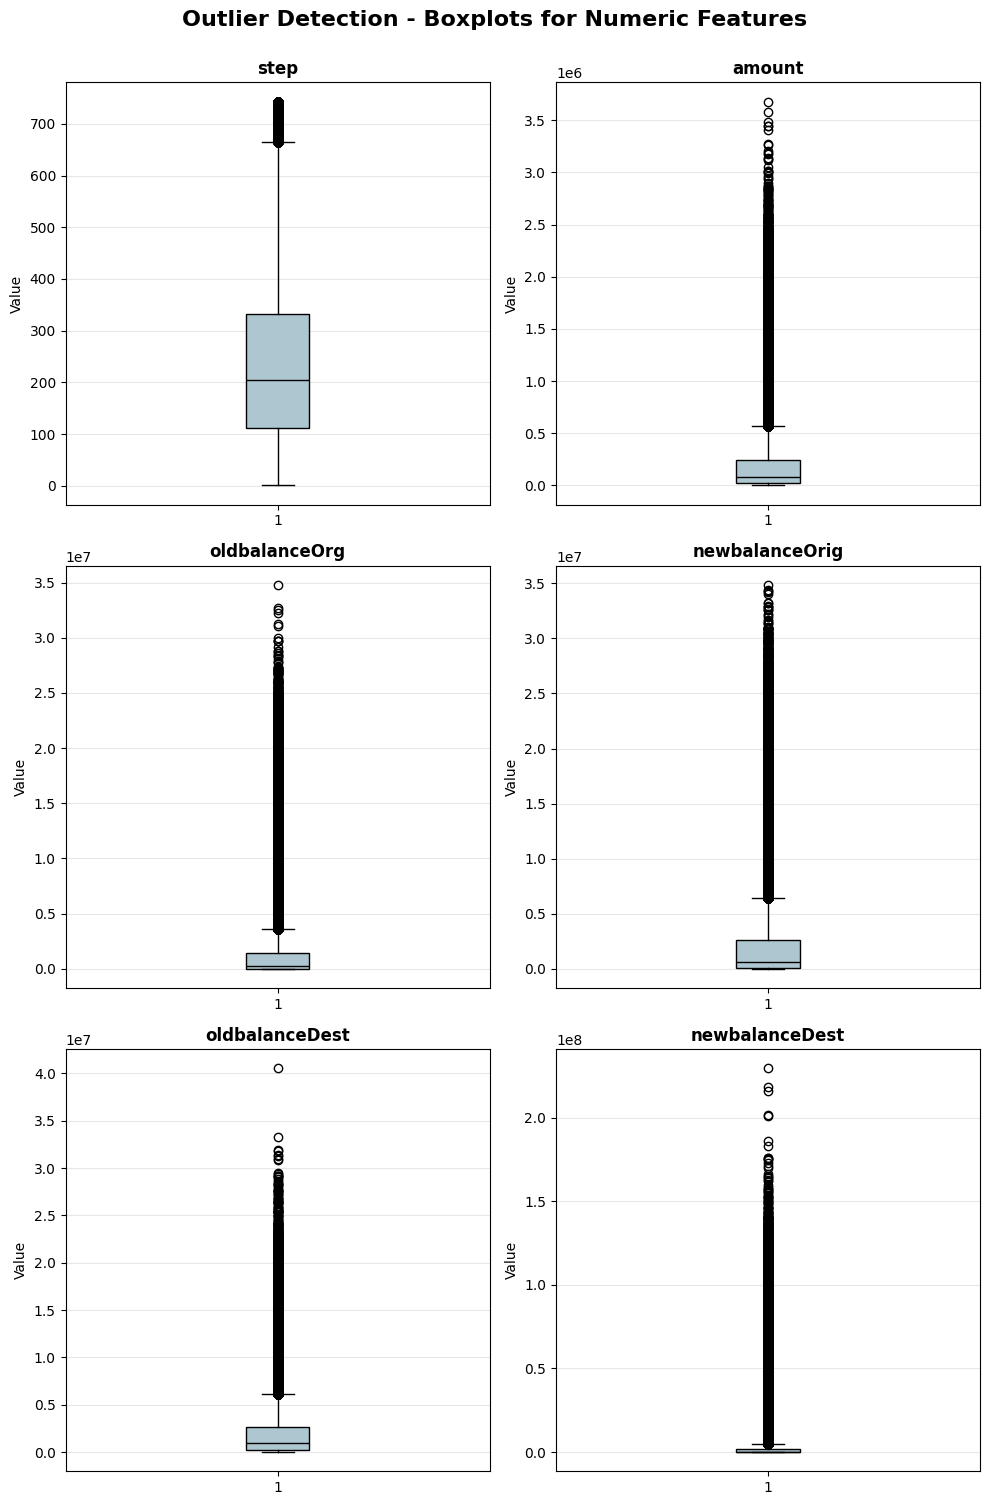

Analyse des outliers terminée - Tous les outliers sont conservés (valeurs réalistes)


In [9]:
print("Génération des boxplots...\n")

n_cols = 2
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df[col],
                    patch_artist=True,
                    boxprops=dict(facecolor="#AEC6CF", color="black"),
                    medianprops=dict(color="black", linewidth=1),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - Boxplots for Numeric Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Analyse des outliers terminée - Tous les outliers sont conservés (valeurs réalistes)")

## Phase 2: Feature Engineering & Variant Generation


#### 2.1. Feature Engineering for Transactions

The `preprocess_transactions` function generates new features to help the model detect fraud.
Features are designed to capture important patterns and behaviors in financial transactions.

Types of features created:
- **Temporal features (2):** `hour` (hour of day), `day` (day number)
- **Transaction type encoding (5):** One-hot encoding of transaction type (CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER)
- **Balance delta features (2):** `delta_sender`, `delta_receiver` (balance changes)
- **Balance consistency checks (4):** `balance_sender_error`, `balance_receiver_error` and their absolute values
- **Amount ratio features (3):** Ratios of transaction amount to sender balances

Total: **13 engineered features** that capture temporal patterns, transaction types, balance inconsistencies, and financial ratios.

Original identifier columns (`nameOrig`, `nameDest`) and flagging column (`isFlaggedFraud`) are dropped to avoid data leakage.
All remaining columns are ensured to be numeric and properly typed for ML algorithms.

In [10]:
print("Feature engineering...")
df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24
df = pd.get_dummies(df, columns=["type"], prefix="type")
df["delta_sender"] = df["newbalanceOrig"] - df["oldbalanceOrg"]
df["abs_delta_sender"] = df["delta_sender"].abs()
df["balance_sender_error"] = df["delta_sender"] + df["amount"]
df["abs_balance_sender_error"] = df["balance_sender_error"].abs()
df["delta_receiver"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["abs_delta_receiver"] = df["delta_receiver"].abs()
df["balance_receiver_error"] = df["delta_receiver"] - df["amount"]
df["abs_balance_receiver_error"] = df["balance_receiver_error"].abs()
df["amount_over_old"] = df["amount"] / (df["oldbalanceOrg"] + 1)
df["amount_over_new"] = df["amount"] / (df["newbalanceOrig"] + 1)
df["amount_over_total"] = df["amount"] / (df["oldbalanceOrg"] + df["newbalanceOrig"] + 1)
df = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])
for col in df.columns:
    if col != 'isFraud':
        df[col] = df[col].astype('float64')
print(f"{df.shape[1]} features")

Feature engineering...
25 features


#### 2.2. Split our dataset in train/test/split

In [11]:
def scale_features(X_tr, X_v, X_te):
    sc = RobustScaler()
    return (
        pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index),
        pd.DataFrame(sc.transform(X_v), columns=X_v.columns, index=X_v.index),
        pd.DataFrame(sc.transform(X_te), columns=X_te.columns, index=X_te.index)
    )

In [12]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(CONFIG['test_size']+CONFIG['val_size']), stratify=y, random_state=42)
val_ratio = CONFIG['val_size'] / (CONFIG['test_size'] + CONFIG['val_size'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1-val_ratio), stratify=y_temp, random_state=42)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
del df, X, y, X_temp, y_temp
gc.collect()
X_train_scaled, X_val_scaled, X_test_scaled = scale_features(X_train, X_val, X_test)

Train: (369229, 24), Val: (79120, 24), Test: (79121, 24)


### 2.2. Systematic Variant Generation

We now generate 43+ preprocessing variants by systematically combining:
1. **Baseline** (no modifications)
2. **Sampling techniques** (undersampling, oversampling, combined)
3. **Feature selection** (tree-based, statistical, wrapper methods)
4. **Dimensionality reduction** (PCA, LDA, SVD, UMAP)
5. **Combined approaches** (sampling + feature selection + dimensionality reduction)

Each variant is saved as train/val/test parquet files with metadata for later evaluation.

In [13]:
def save_dataset(X_train, y_train, X_val, y_val, X_test, y_test, name, meta):
    
    if CONFIG['skip_existing'] and variant_exists(name):
        print(f"{name}: Déjà existant, skip")
        return True
    
    path = os.path.join(CONFIG['output_dir'], name)
    os.makedirs(path, exist_ok=True)
    df_tr = X_train.copy()
    df_tr['isFraud'] = y_train.values if hasattr(y_train, 'values') else y_train
    df_v = X_val.copy()
    df_v['isFraud'] = y_val.values if hasattr(y_val, 'values') else y_val
    df_te = X_test.copy()
    df_te['isFraud'] = y_test.values if hasattr(y_test, 'values') else y_test
    df_tr.to_parquet(f'{path}/train.parquet', index=False)
    df_v.to_parquet(f'{path}/val.parquet', index=False)
    df_te.to_parquet(f'{path}/test.parquet', index=False)
    y_tr = y_train.values if hasattr(y_train, 'values') else y_train
    y_v = y_val.values if hasattr(y_val, 'values') else y_val
    y_te = y_test.values if hasattr(y_test, 'values') else y_test
    meta['shapes'] = {'train': list(df_tr.shape), 'val': list(df_v.shape), 'test': list(df_te.shape)}
    meta['fraud_distribution'] = {
        'train': {str(k): int(v) for k,v in zip(*np.unique(y_tr, return_counts=True))},
        'val': {str(k): int(v) for k,v in zip(*np.unique(y_v, return_counts=True))},
        'test': {str(k): int(v) for k,v in zip(*np.unique(y_te, return_counts=True))}
    }
    meta['created_at'] = datetime.now().isoformat()
    with open(f'{path}/metadata.json', 'w') as f: json.dump(meta, f, indent=2)
    fraud = int(np.sum(y_tr))
    print(f"{name}: {df_tr.shape}, Fraud {fraud} ({fraud/df_tr.shape[0]*100:.1f}%)")
    
    return False

def remove_correlated_features(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop), to_drop

def variant_exists(name):
    '''Vérifie si une variante existe déjà avec tous ses fichiers'''
    path = os.path.join(CONFIG['output_dir'], name)
    if not os.path.exists(path):
        return False
    required_files = ['train.parquet', 'val.parquet', 'test.parquet', 'metadata.json']
    return all(os.path.exists(os.path.join(path, f)) for f in required_files)

print("Fonctions OK")

Fonctions OK


#### A. Baseline (1 variant)

First, we save the baseline dataset with all features, no sampling, no transformations.
This serves as our reference point for comparison.

In [14]:
print("\nGÉNÉRATION DE TOUTES LES VARIANTES\n")
cnt = 0
skipped = 0
generated = 0
generated_total=0
skipped_total=0
cnt_total=0

# BASELINE
cnt += 1
print(f"[{cnt}] Baseline")
if save_dataset(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, 'baseline',
    {'sampling': 'none', 'feature_selection': 'all', 'dim_reduction': 'none'}):
    skipped += 1
else:
    generated += 1
gc.collect()


GÉNÉRATION DE TOUTES LES VARIANTES

[1] Baseline
baseline: (369229, 25), Fraud 19229 (5.2%)


33

#### B. Sampling Techniques (11 variants)

We apply various resampling strategies to handle class imbalance:

**Undersampling (5 methods):**
- Random, Tomek Links, NearMiss, OneSided Selection, Neighbourhood Cleaning Rule

**Oversampling (4 methods):**
- Random, SMOTE, ADASYN, Borderline SMOTE

**Combined (2 methods):**
- SMOTE + Tomek Links, SMOTE + ENN

Note: Sampling is applied only to training data; validation and test sets remain unchanged.

In [15]:
# SAMPLING (11 variantes)
samplers = {
    'undersampling_random': RandomUnderSampler(random_state=42),
    'undersampling_tomek': TomekLinks(),
    'undersampling_nearmiss': NearMiss(version=1),
    'undersampling_onesided': OneSidedSelection(random_state=42),
    'undersampling_ncr': NeighbourhoodCleaningRule(),
    'oversampling_random': RandomOverSampler(random_state=42),
    'oversampling_smote': SMOTE(random_state=42, k_neighbors=3),
    'oversampling_adasyn': ADASYN(random_state=42, n_neighbors=3),
    'oversampling_borderline': BorderlineSMOTE(random_state=42, k_neighbors=3),
    'combined_smote_tomek': SMOTETomek(random_state=42),
    'combined_smote_enn': SMOTEENN(random_state=42)
}
for name, sampler in samplers.items():
    try:
        cnt += 1
        print(f"[{cnt}] {name}")
        
        if CONFIG['skip_existing'] and variant_exists(name):
            print(f"{name}: Déjà existant, skip")
            skipped += 1
            continue
        
        X_r, y_r = sampler.fit_resample(X_train, y_train)
        if not isinstance(X_r, pd.DataFrame): X_r = pd.DataFrame(X_r, columns=X_train.columns)
        if not isinstance(y_r, pd.Series): y_r = pd.Series(y_r, name='isFraud')
        X_s, V_s, T_s = scale_features(X_r, X_val, X_test)
        save_dataset(X_s, y_r, V_s, y_val, T_s, y_test, name,
            {'sampling': name, 'feature_selection': 'all', 'dim_reduction': 'none'})
        generated += 1
        del X_r, y_r, X_s, V_s, T_s
        gc.collect()
    except Exception as e:
        print(f"{name}: {e}")

print(f"\nTerminé ! Généré: {generated}, Skippé: {skipped}, Total: {cnt} variantes")
generated_total=generated_total+generated
skipped_total=skipped_total+skipped
cnt_total=cnt_total+cnt

[2] undersampling_random
undersampling_random: (38458, 25), Fraud 19229 (50.0%)
[3] undersampling_tomek
undersampling_tomek: (360323, 25), Fraud 19229 (5.3%)
[4] undersampling_nearmiss
undersampling_nearmiss: (38458, 25), Fraud 19229 (50.0%)
[5] undersampling_onesided
undersampling_onesided: (360298, 25), Fraud 19229 (5.3%)
[6] undersampling_ncr
undersampling_ncr: (323876, 25), Fraud 19229 (5.9%)
[7] oversampling_random
oversampling_random: (700000, 25), Fraud 350000 (50.0%)
[8] oversampling_smote
oversampling_smote: (700000, 25), Fraud 350000 (50.0%)
[9] oversampling_adasyn
oversampling_adasyn: (703859, 25), Fraud 353859 (50.3%)
[10] oversampling_borderline
oversampling_borderline: (700000, 25), Fraud 350000 (50.0%)
[11] combined_smote_tomek
combined_smote_tomek: (689410, 25), Fraud 344705 (50.0%)
[12] combined_smote_enn
combined_smote_enn: (552714, 25), Fraud 315156 (57.0%)

Terminé ! Généré: 12, Skippé: 0, Total: 12 variantes


#### C. Feature Selection (12 variants)

We select the most informative features using various techniques:

**Tree-based importance (3 methods):**
- ExtraTrees, RandomForest, Permutation Importance

**Statistical tests (5 methods):**
- Mutual Information, Chi2, ANOVA F-test, Variance Threshold, Combined Statistical

**Wrapper methods (2 methods):**
- RFE (Recursive Feature Elimination), L1-Lasso regularization

**Correlation-based (2 methods):**
- Correlation Filter, Permutation Importance

Each method selects the top 10 most important features from the original 24.

In [15]:
# FEATURE SELECTION (12 variantes)

cnt = 0
skipped = 0
generated = 0

cnt += 1
print(f"[{cnt}] ExtraTrees")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_extratrees')):
    et = ExtraTreesClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    et.fit(X_train_scaled, y_train)
    top_et = pd.DataFrame({'f': X_train_scaled.columns, 'i': et.feature_importances_}).nlargest(10, 'i')['f'].tolist()
    save_dataset(X_train_scaled[top_et], y_train, X_val_scaled[top_et], y_val, X_test_scaled[top_et], y_test,
        'feature_selection_extratrees', {'sampling': 'none', 'feature_selection': 'ExtraTrees', 'dim_reduction': 'none'})
    generated += 1
    del et
else:
    print(f"feature_selection_extratrees: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] RandomForest")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_randomforest')):
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    top_rf = pd.DataFrame({'f': X_train_scaled.columns, 'i': rf.feature_importances_}).nlargest(10, 'i')['f'].tolist()
    save_dataset(X_train_scaled[top_rf], y_train, X_val_scaled[top_rf], y_val, X_test_scaled[top_rf], y_test,
        'feature_selection_randomforest', {'sampling': 'none', 'feature_selection': 'RandomForest', 'dim_reduction': 'none'})
    generated += 1
    del rf
else:
    print(f"feature_selection_randomforest: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Mutual Info")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_mutual_info')):
    sel_mi = SelectKBest(mutual_info_classif, k=10)
    sel_mi.fit(X_train_scaled, y_train)
    feat_mi = X_train_scaled.columns[sel_mi.get_support()].tolist()
    save_dataset(pd.DataFrame(sel_mi.transform(X_train_scaled), columns=feat_mi, index=X_train_scaled.index), y_train,
        pd.DataFrame(sel_mi.transform(X_val_scaled), columns=feat_mi, index=X_val_scaled.index), y_val,
        pd.DataFrame(sel_mi.transform(X_test_scaled), columns=feat_mi, index=X_test_scaled.index), y_test,
        'feature_selection_mutual_info', {'sampling': 'none', 'feature_selection': 'MutualInfo', 'dim_reduction': 'none'})
    generated += 1
    del sel_mi
else:
    print(f"feature_selection_mutual_info: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Chi2")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_chi2')):
    X_pos = X_train_scaled - X_train_scaled.min() + 1e-10
    sel_chi = SelectKBest(chi2, k=10)
    sel_chi.fit(X_pos, y_train)
    feat_chi = X_train_scaled.columns[sel_chi.get_support()].tolist()
    save_dataset(pd.DataFrame(sel_chi.transform(X_pos), columns=feat_chi, index=X_train_scaled.index), y_train,
        pd.DataFrame(sel_chi.transform(X_val_scaled-X_val_scaled.min()+1e-10), columns=feat_chi, index=X_val_scaled.index), y_val,
        pd.DataFrame(sel_chi.transform(X_test_scaled-X_test_scaled.min()+1e-10), columns=feat_chi, index=X_test_scaled.index), y_test,
        'feature_selection_chi2', {'sampling': 'none', 'feature_selection': 'Chi2', 'dim_reduction': 'none'})
    generated += 1
    del sel_chi, X_pos
else:
    print(f"feature_selection_chi2: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] ANOVA")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_anova')):
    sel_an = SelectKBest(f_classif, k=10)
    sel_an.fit(X_train_scaled, y_train)
    feat_an = X_train_scaled.columns[sel_an.get_support()].tolist()
    save_dataset(pd.DataFrame(sel_an.transform(X_train_scaled), columns=feat_an, index=X_train_scaled.index), y_train,
        pd.DataFrame(sel_an.transform(X_val_scaled), columns=feat_an, index=X_val_scaled.index), y_val,
        pd.DataFrame(sel_an.transform(X_test_scaled), columns=feat_an, index=X_test_scaled.index), y_test,
        'feature_selection_anova', {'sampling': 'none', 'feature_selection': 'ANOVA', 'dim_reduction': 'none'})
    generated += 1
    del sel_an
else:
    print(f"feature_selection_anova: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Variance")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_variance')):
    sel_var = VarianceThreshold(0.1)
    sel_var.fit(X_train_scaled)
    feat_var = X_train_scaled.columns[sel_var.get_support()].tolist()
    if len(feat_var) > 10: feat_var = X_train_scaled[feat_var].var().nlargest(10).index.tolist()
    save_dataset(X_train_scaled[feat_var], y_train, X_val_scaled[feat_var], y_val, X_test_scaled[feat_var], y_test,
        'feature_selection_variance', {'sampling': 'none', 'feature_selection': 'Variance', 'dim_reduction': 'none'})
    generated += 1
    del sel_var
else:
    print(f"feature_selection_variance: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] RFE")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_rfe')):
    rfe = RFE(LogisticRegression(max_iter=500, random_state=42), n_features_to_select=10)
    rfe.fit(X_train_scaled, y_train)
    feat_rfe = X_train_scaled.columns[rfe.get_support()].tolist()
    save_dataset(pd.DataFrame(rfe.transform(X_train_scaled), columns=feat_rfe, index=X_train_scaled.index), y_train,
        pd.DataFrame(rfe.transform(X_val_scaled), columns=feat_rfe, index=X_val_scaled.index), y_val,
        pd.DataFrame(rfe.transform(X_test_scaled), columns=feat_rfe, index=X_test_scaled.index), y_test,
        'feature_selection_rfe', {'sampling': 'none', 'feature_selection': 'RFE', 'dim_reduction': 'none'})
    generated += 1
    del rfe
else:
    print(f"feature_selection_rfe: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] L1-Lasso")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_l1_lasso')):
    lasso = LassoCV(cv=3, random_state=42, max_iter=1000, n_jobs=-1)
    lasso.fit(X_train_scaled, y_train)
    feat_l1 = pd.Series(np.abs(lasso.coef_), index=X_train_scaled.columns).nlargest(10).index.tolist()
    save_dataset(X_train_scaled[feat_l1], y_train, X_val_scaled[feat_l1], y_val, X_test_scaled[feat_l1], y_test,
        'feature_selection_l1_lasso', {'sampling': 'none', 'feature_selection': 'L1_Lasso', 'dim_reduction': 'none'})
    generated += 1
    del lasso
else:
    print(f"feature_selection_l1_lasso: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Correlation Filter")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_correlation')):
    X_uncorr, dropped = remove_correlated_features(X_train_scaled, CONFIG['correlation_threshold'])
    print(f"  Dropped {len(dropped)} correlated features")
    if X_uncorr.shape[1] > 10:
        top_var = X_uncorr.var().nlargest(10).index.tolist()
        X_uncorr = X_uncorr[top_var]
    feat_corr = X_uncorr.columns.tolist()
    save_dataset(X_uncorr, y_train, X_val_scaled[feat_corr], y_val, X_test_scaled[feat_corr], y_test,
        'feature_selection_correlation', {'sampling': 'none', 'feature_selection': 'Correlation', 'dim_reduction': 'none'})
    generated += 1
    del X_uncorr
else:
    print(f"feature_selection_correlation: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Permutation Importance")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_permutation')):
    rf_perm = RandomForestClassifier(n_estimators=30, max_depth=8, random_state=42, n_jobs=-1)
    rf_perm.fit(X_train_scaled, y_train)
    perm = permutation_importance(rf_perm, X_train_scaled, y_train, n_repeats=5, random_state=42, n_jobs=-1)
    feat_perm = pd.Series(perm.importances_mean, index=X_train_scaled.columns).nlargest(10).index.tolist()
    save_dataset(X_train_scaled[feat_perm], y_train, X_val_scaled[feat_perm], y_val, X_test_scaled[feat_perm], y_test,
        'feature_selection_permutation', {'sampling': 'none', 'feature_selection': 'Permutation', 'dim_reduction': 'none'})
    generated += 1
    del rf_perm, perm
else:
    print(f"feature_selection_permutation: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Combined Statistical")
if not (CONFIG['skip_existing'] and variant_exists('feature_selection_combined_stat')):
    s_mi = SelectKBest(mutual_info_classif, k='all')
    s_mi.fit(X_train_scaled, y_train)
    sc_mi = pd.Series(s_mi.scores_, index=X_train_scaled.columns)
    sc_var = X_train_scaled.var()
    s_an = SelectKBest(f_classif, k='all')
    s_an.fit(X_train_scaled, y_train)
    sc_an = pd.Series(s_an.scores_, index=X_train_scaled.columns)
    sc_mi_n = (sc_mi - sc_mi.min()) / (sc_mi.max() - sc_mi.min())
    sc_var_n = (sc_var - sc_var.min()) / (sc_var.max() - sc_var.min())
    sc_an_n = (sc_an - sc_an.min()) / (sc_an.max() - sc_an.min())
    sc_comb = (sc_mi_n + sc_var_n + sc_an_n) / 3
    feat_comb = sc_comb.nlargest(10).index.tolist()
    save_dataset(X_train_scaled[feat_comb], y_train, X_val_scaled[feat_comb], y_val, X_test_scaled[feat_comb], y_test,
        'feature_selection_combined_stat', {'sampling': 'none', 'feature_selection': 'Combined_Statistical', 'dim_reduction': 'none'})
    generated += 1
    del s_mi, s_an
else:
    print(f"feature_selection_combined_stat: Déjà existant, skip")
    skipped += 1
gc.collect()

print(f"\nTerminé ! Généré: {generated}, Skippé: {skipped}, Total: {cnt} variantes")
generated_total=generated_total+generated
skipped_total=skipped_total+skipped
cnt_total=cnt_total+cnt

[1] ExtraTrees
feature_selection_extratrees: (369229, 11), Fraud 19229 (5.2%)
[2] RandomForest
feature_selection_randomforest: (369229, 11), Fraud 19229 (5.2%)
[3] Mutual Info
feature_selection_mutual_info: (369229, 11), Fraud 19229 (5.2%)
[4] Chi2
feature_selection_chi2: (369229, 11), Fraud 19229 (5.2%)
[5] ANOVA
feature_selection_anova: (369229, 11), Fraud 19229 (5.2%)
[6] Variance
feature_selection_variance: (369229, 11), Fraud 19229 (5.2%)
[7] RFE
feature_selection_rfe: (369229, 11), Fraud 19229 (5.2%)
[8] L1-Lasso
feature_selection_l1_lasso: (369229, 11), Fraud 19229 (5.2%)
[9] Correlation Filter
  Dropped 7 correlated features
feature_selection_correlation: (369229, 11), Fraud 19229 (5.2%)
[10] Permutation Importance
feature_selection_permutation: (369229, 11), Fraud 19229 (5.2%)
[11] Combined Statistical
feature_selection_combined_stat: (369229, 11), Fraud 19229 (5.2%)

Terminé ! Généré: 11, Skippé: 0, Total: 11 variantes


#### D. Dimensionality Reduction (5 variants)

We reduce the feature space while preserving maximum information:

**Linear methods (3):**
- PCA (8 components), LDA (1 component), SVD (8 components)

**Non-linear method (1):**
- UMAP (8 components)

**Optional (1):**
- Kernel PCA (enabled via CONFIG)

Note: Dimensionality reduction transforms features into new representations, which may reduce interpretability for XAI tools like SHAP.

In [16]:
cnt = 0
skipped = 0
generated = 0

# DIMENSIONALITY REDUCTION (4-5 variantes selon config)
cnt += 1
print(f"[{cnt}] PCA")
if not (CONFIG['skip_existing'] and variant_exists('dim_reduction_pca')):
    pca = PCA(n_components=8, random_state=42)
    Xtr = pd.DataFrame(pca.fit_transform(X_train_scaled), columns=[f'PC{i+1}' for i in range(8)], index=X_train_scaled.index)
    Xv = pd.DataFrame(pca.transform(X_val_scaled), columns=[f'PC{i+1}' for i in range(8)], index=X_val_scaled.index)
    Xte = pd.DataFrame(pca.transform(X_test_scaled), columns=[f'PC{i+1}' for i in range(8)], index=X_test_scaled.index)
    save_dataset(Xtr, y_train, Xv, y_val, Xte, y_test, 'dim_reduction_pca',
        {'sampling': 'none', 'feature_selection': 'none', 'dim_reduction': 'PCA'})
    generated += 1
    del pca, Xtr, Xv, Xte
else:
    print(f"dim_reduction_pca: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] LDA")
if not (CONFIG['skip_existing'] and variant_exists('dim_reduction_lda')):
    lda = LDA(n_components=1)
    Xtr = pd.DataFrame(lda.fit_transform(X_train_scaled, y_train), columns=['LD1'], index=X_train_scaled.index)
    Xv = pd.DataFrame(lda.transform(X_val_scaled), columns=['LD1'], index=X_val_scaled.index)
    Xte = pd.DataFrame(lda.transform(X_test_scaled), columns=['LD1'], index=X_test_scaled.index)
    save_dataset(Xtr, y_train, Xv, y_val, Xte, y_test, 'dim_reduction_lda',
        {'sampling': 'none', 'feature_selection': 'none', 'dim_reduction': 'LDA'})
    generated += 1
    del lda, Xtr, Xv, Xte
else:
    print(f"dim_reduction_lda: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Truncated SVD")
if not (CONFIG['skip_existing'] and variant_exists('dim_reduction_svd')):
    svd = TruncatedSVD(n_components=8, random_state=42)
    Xtr = pd.DataFrame(svd.fit_transform(X_train_scaled), columns=[f'SVD{i+1}' for i in range(8)], index=X_train_scaled.index)
    Xv = pd.DataFrame(svd.transform(X_val_scaled), columns=[f'SVD{i+1}' for i in range(8)], index=X_val_scaled.index)
    Xte = pd.DataFrame(svd.transform(X_test_scaled), columns=[f'SVD{i+1}' for i in range(8)], index=X_test_scaled.index)
    save_dataset(Xtr, y_train, Xv, y_val, Xte, y_test, 'dim_reduction_svd',
        {'sampling': 'none', 'feature_selection': 'none', 'dim_reduction': 'TruncatedSVD'})
    generated += 1
    del svd, Xtr, Xv, Xte
else:
    print(f"dim_reduction_svd: Déjà existant, skip")
    skipped += 1
gc.collect()

# KERNEL PCA - OPTIONNEL (désactivé par défaut)
if CONFIG['enable_kernel_pca']:
    cnt += 1
    print(f"[{cnt}] Kernel PCA (RBF) - échantillon {CONFIG['kernel_pca_sample_size']}")
    if not (CONFIG['skip_existing'] and variant_exists('dim_reduction_kernel_pca')):
        print("  Cela peut prendre plusieurs minutes...")
        sample_size = min(CONFIG['kernel_pca_sample_size'], len(X_train_scaled))
        sample_idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)
        X_sample = X_train_scaled.iloc[sample_idx]
        kpca = KernelPCA(n_components=8, kernel='rbf', random_state=42, n_jobs=-1)
        kpca.fit(X_sample)
        Xtr = pd.DataFrame(kpca.transform(X_train_scaled), columns=[f'KPCA{i+1}' for i in range(8)], index=X_train_scaled.index)
        Xv = pd.DataFrame(kpca.transform(X_val_scaled), columns=[f'KPCA{i+1}' for i in range(8)], index=X_val_scaled.index)
        Xte = pd.DataFrame(kpca.transform(X_test_scaled), columns=[f'KPCA{i+1}' for i in range(8)], index=X_test_scaled.index)
        save_dataset(Xtr, y_train, Xv, y_val, Xte, y_test, 'dim_reduction_kernel_pca',
            {'sampling': 'none', 'feature_selection': 'none', 'dim_reduction': 'KernelPCA_RBF'})
        generated += 1
        del kpca, Xtr, Xv, Xte, X_sample
    else:
        print(f"dim_reduction_kernel_pca: Déjà existant, skip")
        skipped += 1
    gc.collect()
else:
    print(f"Kernel PCA désactivé (activez dans CONFIG si besoin)")

if UMAP_AVAILABLE:
    cnt += 1
    print(f"[{cnt}] UMAP")
    if not (CONFIG['skip_existing'] and variant_exists('dim_reduction_umap')):
        um = umap.UMAP(n_components=8, n_neighbors=15, random_state=42)
        Xtr = pd.DataFrame(um.fit_transform(X_train_scaled, y=y_train), columns=[f'U{i+1}' for i in range(8)], index=X_train_scaled.index)
        Xv = pd.DataFrame(um.transform(X_val_scaled), columns=[f'U{i+1}' for i in range(8)], index=X_val_scaled.index)
        Xte = pd.DataFrame(um.transform(X_test_scaled), columns=[f'U{i+1}' for i in range(8)], index=X_test_scaled.index)
        save_dataset(Xtr, y_train, Xv, y_val, Xte, y_test, 'dim_reduction_umap',
            {'sampling': 'none', 'feature_selection': 'none', 'dim_reduction': 'UMAP'})
        generated += 1
        del um, Xtr, Xv, Xte
    else:
        print(f"dim_reduction_umap: Déjà existant, skip")
        skipped += 1
    gc.collect()

print(f"\nTerminé ! Généré: {generated}, Skippé: {skipped}, Total: {cnt} variantes")
generated_total=generated_total+generated
skipped_total=skipped_total+skipped
cnt_total=cnt_total+cnt

[1] PCA
dim_reduction_pca: (369229, 9), Fraud 19229 (5.2%)
[2] LDA
dim_reduction_lda: (369229, 2), Fraud 19229 (5.2%)
[3] Truncated SVD
dim_reduction_svd: (369229, 9), Fraud 19229 (5.2%)
Kernel PCA désactivé (activez dans CONFIG si besoin)

Terminé ! Généré: 3, Skippé: 0, Total: 3 variantes


#### E. Combined Approaches (10+ variants)

We combine multiple preprocessing techniques to potentially achieve better results:

**Sampling + Dimensionality Reduction:**
- SMOTE + PCA, SMOTE + LDA, Undersampling + LDA

**Sampling + Feature Selection:**
- SMOTE + RFE, SMOTE + Correlation, SMOTE + Statistical, Undersampling + Mutual Info

**Sampling + Feature Selection + Dimensionality Reduction:**
- SMOTE + Statistical + SVD, Undersampling + ExtraTrees + LDA, ADASYN + Permutation + PCA, SMOTETomek + RFE + PCA

These combinations explore the synergy between different preprocessing methods to optimize fraud detection performance.

In [17]:
cnt = 0
skipped = 0
generated = 0

# COMBINAISONS (10 variantes)
cnt += 1
print(f"[{cnt}] SMOTE + PCA")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_pca')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    p = PCA(8, random_state=42)
    Xp = pd.DataFrame(p.fit_transform(Xs_sc), columns=[f'PC{i+1}' for i in range(8)])
    Vp = pd.DataFrame(p.transform(X_val_scaled), columns=[f'PC{i+1}' for i in range(8)], index=X_val_scaled.index)
    Tp = pd.DataFrame(p.transform(X_test_scaled), columns=[f'PC{i+1}' for i in range(8)], index=X_test_scaled.index)
    save_dataset(Xp, ys, Vp, y_val, Tp, y_test, 'combined_smote_pca',
        {'sampling': 'SMOTE', 'feature_selection': 'none', 'dim_reduction': 'PCA'})
    generated += 1
    del sm, p, Xs, ys, Xs_sc, Xp, Vp, Tp
else:
    print(f"combined_smote_pca: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Undersampling + MI")
if not (CONFIG['skip_existing'] and variant_exists('combined_undersampling_mi')):
    ru = RandomUnderSampler(random_state=42)
    Xr, yr = ru.fit_resample(X_train, y_train)
    if not isinstance(Xr, pd.DataFrame): Xr = pd.DataFrame(Xr, columns=X_train.columns)
    if not isinstance(yr, pd.Series): yr = pd.Series(yr, name='isFraud')
    Xr_sc, _, _ = scale_features(Xr, X_val, X_test)
    sm = SelectKBest(mutual_info_classif, k=10)
    sm.fit(Xr_sc, yr)
    fm = X_train.columns[sm.get_support()].tolist()
    save_dataset(pd.DataFrame(sm.transform(Xr_sc), columns=fm), yr,
        pd.DataFrame(sm.transform(X_val_scaled), columns=fm, index=X_val_scaled.index), y_val,
        pd.DataFrame(sm.transform(X_test_scaled), columns=fm, index=X_test_scaled.index), y_test,
        'combined_undersampling_mi', {'sampling': 'Undersampling', 'feature_selection': 'MI', 'dim_reduction': 'none'})
    generated += 1
    del ru, sm, Xr, yr, Xr_sc
else:
    print(f"combined_undersampling_mi: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTE + LDA")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_lda')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    ld = LDA(n_components=1)
    Xl = pd.DataFrame(ld.fit_transform(Xs_sc, ys), columns=['LD1'])
    Vl = pd.DataFrame(ld.transform(X_val_scaled), columns=['LD1'], index=X_val_scaled.index)
    Tl = pd.DataFrame(ld.transform(X_test_scaled), columns=['LD1'], index=X_test_scaled.index)
    save_dataset(Xl, ys, Vl, y_val, Tl, y_test, 'combined_smote_lda',
        {'sampling': 'SMOTE', 'feature_selection': 'none', 'dim_reduction': 'LDA'})
    generated += 1
    del sm, ld, Xs, ys, Xs_sc, Xl, Vl, Tl
else:
    print(f"combined_smote_lda: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTE + RFE")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_rfe')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    rf = RFE(LogisticRegression(max_iter=500, random_state=42), n_features_to_select = 10)
    rf.fit(Xs_sc, ys)
    fr = X_train.columns[rf.get_support()].tolist()
    save_dataset(pd.DataFrame(rf.transform(Xs_sc), columns=fr), ys,
        pd.DataFrame(rf.transform(X_val_scaled), columns=fr, index=X_val_scaled.index), y_val,
        pd.DataFrame(rf.transform(X_test_scaled), columns=fr, index=X_test_scaled.index), y_test,
        'combined_smote_rfe', {'sampling': 'SMOTE', 'feature_selection': 'RFE', 'dim_reduction': 'none'})
    generated += 1
    del sm, rf, Xs, ys, Xs_sc
else:
    print(f"combined_smote_rfe: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTE + Combined Statistical")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_statistical')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    s1 = SelectKBest(mutual_info_classif, k='all')
    s1.fit(Xs_sc, ys)
    m1 = pd.Series(s1.scores_, index=X_train.columns)
    v1 = Xs_sc.var()
    s2 = SelectKBest(f_classif, k='all')
    s2.fit(Xs_sc, ys)
    a1 = pd.Series(s2.scores_, index=X_train.columns)
    m1n = (m1-m1.min())/(m1.max()-m1.min())
    v1n = (v1-v1.min())/(v1.max()-v1.min())
    a1n = (a1-a1.min())/(a1.max()-a1.min())
    c1 = (m1n+v1n+a1n)/3
    fc = c1.nlargest(10).index.tolist()
    save_dataset(Xs_sc[fc], ys, X_val_scaled[fc], y_val, X_test_scaled[fc], y_test,
        'combined_smote_statistical', {'sampling': 'SMOTE', 'feature_selection': 'Combined', 'dim_reduction': 'none'})
    generated += 1
    del sm, s1, s2, Xs, ys, Xs_sc
else:
    print(f"combined_smote_statistical: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTE + Correlation + PCA")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_corr_pca')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    Xunc, _ = remove_correlated_features(Xs_sc, 0.95)
    nc = min(8, Xunc.shape[1])
    p = PCA(nc, random_state=42)
    Xp = pd.DataFrame(p.fit_transform(Xunc), columns=[f'PC{i+1}' for i in range(nc)])
    Vp = pd.DataFrame(p.transform(X_val_scaled[Xunc.columns]), columns=[f'PC{i+1}' for i in range(nc)], index=X_val_scaled.index)
    Tp = pd.DataFrame(p.transform(X_test_scaled[Xunc.columns]), columns=[f'PC{i+1}' for i in range(nc)], index=X_test_scaled.index)
    save_dataset(Xp, ys, Vp, y_val, Tp, y_test, 'combined_smote_corr_pca',
        {'sampling': 'SMOTE', 'feature_selection': 'Correlation', 'dim_reduction': 'PCA'})
    generated += 1
    del sm, Xs, ys, Xs_sc, Xunc, p, Xp, Vp, Tp
else:
    print(f"combined_smote_corr_pca: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] Undersampling + Tree + LDA")
if not (CONFIG['skip_existing'] and variant_exists('combined_under_tree_lda')):
    ru = RandomUnderSampler(random_state=42)
    Xr, yr = ru.fit_resample(X_train, y_train)
    if not isinstance(Xr, pd.DataFrame): Xr = pd.DataFrame(Xr, columns=X_train.columns)
    if not isinstance(yr, pd.Series): yr = pd.Series(yr, name='isFraud')
    Xr_sc, _, _ = scale_features(Xr, X_val, X_test)
    et = ExtraTreesClassifier(n_estimators=30, max_depth=8, random_state=42, n_jobs=-1)
    et.fit(Xr_sc, yr)
    top = pd.DataFrame({'f': X_train.columns, 'i': et.feature_importances_}).nlargest(15, 'i')['f'].tolist()
    ld = LDA(n_components=1)
    Xl = pd.DataFrame(ld.fit_transform(Xr_sc[top], yr), columns=['LD1'])
    Vl = pd.DataFrame(ld.transform(X_val_scaled[top]), columns=['LD1'], index=X_val_scaled.index)
    Tl = pd.DataFrame(ld.transform(X_test_scaled[top]), columns=['LD1'], index=X_test_scaled.index)
    save_dataset(Xl, yr, Vl, y_val, Tl, y_test, 'combined_under_tree_lda',
        {'sampling': 'Undersampling', 'feature_selection': 'ExtraTrees', 'dim_reduction': 'LDA'})
    generated += 1
    del ru, et, Xr, yr, Xr_sc, ld, Xl, Vl, Tl
else:
    print(f"combined_under_tree_lda: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] ADASYN + Permutation + PCA")
if not (CONFIG['skip_existing'] and variant_exists('combined_adasyn_perm_pca')):
    ad = ADASYN(random_state=42, n_neighbors=3)
    Xa, ya = ad.fit_resample(X_train, y_train)
    if not isinstance(Xa, pd.DataFrame): Xa = pd.DataFrame(Xa, columns=X_train.columns)
    if not isinstance(ya, pd.Series): ya = pd.Series(ya, name='isFraud')
    Xa_sc, _, _ = scale_features(Xa, X_val, X_test)
    rf = RandomForestClassifier(n_estimators=20, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(Xa_sc, ya)
    perm = permutation_importance(rf, Xa_sc, ya, n_repeats=3, random_state=42, n_jobs=-1)
    top_p = pd.Series(perm.importances_mean, index=X_train.columns).nlargest(15).index.tolist()
    nc = min(8, len(top_p))
    p = PCA(nc, random_state=42)
    Xp = pd.DataFrame(p.fit_transform(Xa_sc[top_p]), columns=[f'PC{i+1}' for i in range(nc)])
    Vp = pd.DataFrame(p.transform(X_val_scaled[top_p]), columns=[f'PC{i+1}' for i in range(nc)], index=X_val_scaled.index)
    Tp = pd.DataFrame(p.transform(X_test_scaled[top_p]), columns=[f'PC{i+1}' for i in range(nc)], index=X_test_scaled.index)
    save_dataset(Xp, ya, Vp, y_val, Tp, y_test, 'combined_adasyn_perm_pca',
        {'sampling': 'ADASYN', 'feature_selection': 'Permutation', 'dim_reduction': 'PCA'})
    generated += 1
    del ad, Xa, ya, Xa_sc, rf, perm, p, Xp, Vp, Tp
else:
    print(f"combined_adasyn_perm_pca: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTE + L1 + SVD")
if not (CONFIG['skip_existing'] and variant_exists('combined_smote_l1_svd')):
    sm = SMOTE(random_state=42, k_neighbors=3)
    Xs, ys = sm.fit_resample(X_train, y_train)
    if not isinstance(Xs, pd.DataFrame): Xs = pd.DataFrame(Xs, columns=X_train.columns)
    if not isinstance(ys, pd.Series): ys = pd.Series(ys, name='isFraud')
    Xs_sc, _, _ = scale_features(Xs, X_val, X_test)
    las = LassoCV(cv=3, random_state=42, max_iter=500)
    las.fit(Xs_sc, ys)
    top_l1 = pd.Series(np.abs(las.coef_), index=X_train.columns).nlargest(15).index.tolist()
    nc = min(8, len(top_l1))
    sv = TruncatedSVD(nc, random_state=42)
    Xsv = pd.DataFrame(sv.fit_transform(Xs_sc[top_l1]), columns=[f'SVD{i+1}' for i in range(nc)])
    Vsv = pd.DataFrame(sv.transform(X_val_scaled[top_l1]), columns=[f'SVD{i+1}' for i in range(nc)], index=X_val_scaled.index)
    Tsv = pd.DataFrame(sv.transform(X_test_scaled[top_l1]), columns=[f'SVD{i+1}' for i in range(nc)], index=X_test_scaled.index)
    save_dataset(Xsv, ys, Vsv, y_val, Tsv, y_test, 'combined_smote_l1_svd',
        {'sampling': 'SMOTE', 'feature_selection': 'L1_Lasso', 'dim_reduction': 'SVD'})
    generated += 1
    del sm, Xs, ys, Xs_sc, las, sv, Xsv, Vsv, Tsv
else:
    print(f"combined_smote_l1_svd: Déjà existant, skip")
    skipped += 1
gc.collect()

cnt += 1
print(f"[{cnt}] SMOTETomek + RFE + PCA")
if not (CONFIG['skip_existing'] and variant_exists('combined_smotetomek_rfe_pca')):
    st = SMOTETomek(random_state=42)
    Xst, yst = st.fit_resample(X_train, y_train)
    if not isinstance(Xst, pd.DataFrame): Xst = pd.DataFrame(Xst, columns=X_train.columns)
    if not isinstance(yst, pd.Series): yst = pd.Series(yst, name='isFraud')
    Xst_sc, _, _ = scale_features(Xst, X_val, X_test)
    rf = RFE(LogisticRegression(max_iter=300, random_state=42), n_features_to_select=12)
    rf.fit(Xst_sc, yst)
    feat_rf = X_train.columns[rf.get_support()].tolist()
    nc = min(8, len(feat_rf))
    p = PCA(nc, random_state=42)
    Xp = pd.DataFrame(p.fit_transform(Xst_sc[feat_rf]), columns=[f'PC{i+1}' for i in range(nc)])
    Vp = pd.DataFrame(p.transform(X_val_scaled[feat_rf]), columns=[f'PC{i+1}' for i in range(nc)], index=X_val_scaled.index)
    Tp = pd.DataFrame(p.transform(X_test_scaled[feat_rf]), columns=[f'PC{i+1}' for i in range(nc)], index=X_test_scaled.index)
    save_dataset(Xp, yst, Vp, y_val, Tp, y_test, 'combined_smotetomek_rfe_pca',
        {'sampling': 'SMOTETomek', 'feature_selection': 'RFE', 'dim_reduction': 'PCA'})
    generated += 1
    del st, Xst, yst, Xst_sc, rf, p, Xp, Vp, Tp
else:
    print(f"combined_smotetomek_rfe_pca: Déjà existant, skip")
    skipped += 1
gc.collect()


print(f"\nTerminé ! Généré: {generated}, Skippé: {skipped}, Total: {cnt} variantes")
generated_total=generated_total+generated
skipped_total=skipped_total+skipped
cnt_total=cnt_total+cnt


[1] SMOTE + PCA
combined_smote_pca: (700000, 9), Fraud 350000 (50.0%)
[2] Undersampling + MI
combined_undersampling_mi: (38458, 11), Fraud 19229 (50.0%)
[3] SMOTE + LDA
combined_smote_lda: (700000, 2), Fraud 350000 (50.0%)
[4] SMOTE + RFE
combined_smote_rfe: (700000, 11), Fraud 350000 (50.0%)
[5] SMOTE + Combined Statistical
combined_smote_statistical: (700000, 11), Fraud 350000 (50.0%)
[6] SMOTE + Correlation + PCA
combined_smote_corr_pca: (700000, 9), Fraud 350000 (50.0%)
[7] Undersampling + Tree + LDA
combined_under_tree_lda: (38458, 2), Fraud 19229 (50.0%)
[8] ADASYN + Permutation + PCA
combined_adasyn_perm_pca: (703859, 9), Fraud 353859 (50.3%)
[9] SMOTE + L1 + SVD
combined_smote_l1_svd: (700000, 9), Fraud 350000 (50.0%)
[10] SMOTETomek + RFE + PCA
combined_smotetomek_rfe_pca: (689410, 9), Fraud 344705 (50.0%)

Terminé ! Généré: 10, Skippé: 0, Total: 10 variantes


#### F. Final Summary

In [18]:
print(f"\nTerminé ! Généré: {generated_total}, Skippé: {skipped_total}, Total: {cnt_total} variantes")


Terminé ! Généré: 24, Skippé: 0, Total: 24 variantes


In [19]:
print("\nRÉSUMÉ FINAL\n")
vlist = sorted([d for d in os.listdir(CONFIG['output_dir']) if os.path.isdir(os.path.join(CONFIG['output_dir'], d))])
summary = []
for v in vlist:
    mpath = os.path.join(CONFIG['output_dir'], v, 'metadata.json')
    if os.path.exists(mpath):
        with open(mpath) as f: m = json.load(f)
        ts = m['shapes']['train']
        fc = m['fraud_distribution']['train'].get('1', 0)
        summary.append({
            'Variant': v,
            'Sampling': m['sampling'],
            'FeatureSel': m['feature_selection'],
            'DimRed': m['dim_reduction'],
            'Shape': f"{ts[0]}x{ts[1]}",
            'Fraud%': f"{fc/ts[0]*100:.1f}%"
        })
df_sum = pd.DataFrame(summary)
print(df_sum.to_string(index=False))
df_sum.to_csv(os.path.join(CONFIG['output_dir'], 'summary.csv'), index=False)
print(f"\n{len(vlist)} variantes dans {CONFIG['output_dir']}")
print(f"summary.csv: {CONFIG['output_dir']}/summary.csv")
print("\nPour activer Kernel PCA: CONFIG['enable_kernel_pca'] = True")
print("Pour regénérer tout: CONFIG['skip_existing'] = False")


RÉSUMÉ FINAL

                        Variant                Sampling           FeatureSel       DimRed     Shape Fraud%
                       baseline                    none                  all         none 369229x25   5.2%
       combined_adasyn_perm_pca                  ADASYN          Permutation          PCA  703859x9  50.3%
        combined_smote_corr_pca                   SMOTE          Correlation          PCA  700000x9  50.0%
             combined_smote_enn      combined_smote_enn                  all         none 552714x25  57.0%
          combined_smote_l1_svd                   SMOTE             L1_Lasso          SVD  700000x9  50.0%
             combined_smote_lda                   SMOTE                 none          LDA  700000x2  50.0%
             combined_smote_pca                   SMOTE                 none          PCA  700000x9  50.0%
             combined_smote_rfe                   SMOTE                  RFE         none 700000x11  50.0%
     combined_smote_st

## Phase 3: Model Evaluation

Now that all variants are generated, we evaluate each one using XGBoost to identify the best preprocessing strategy for fraud detection.

In [57]:
# Configuration XGBoost simple
XGB_PARAMS_BASE = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss'
}

print("Configuration XGBoost simple pour comparaison de datasets:")
for key, value in XGB_PARAMS_BASE.items():
    print(f"  {key}: {value}")


Configuration XGBoost simple pour comparaison de datasets:
  n_estimators: 100
  max_depth: 5
  learning_rate: 0.1
  random_state: 42
  n_jobs: -1
  eval_metric: logloss


### 3.1. XGBoost Configuration

Simple XGBoost configuration to compare preprocessing variants fairly.

In [58]:
def evaluate_variant(variant_name):
    """Charge un dataset, entraîne XGBoost simple et retourne les métriques"""
    try:
        path = os.path.join(CONFIG['output_dir'], variant_name)
        
        # Chargement des données
        df_train = pd.read_parquet(f'{path}/train.parquet')
        df_val = pd.read_parquet(f'{path}/val.parquet')
        df_test = pd.read_parquet(f'{path}/test.parquet')
        
        # Séparation X/y
        X_tr, y_tr = df_train.drop('isFraud', axis=1), df_train['isFraud']
        X_v, y_v = df_val.drop('isFraud', axis=1), df_val['isFraud']
        X_te, y_te = df_test.drop('isFraud', axis=1), df_test['isFraud']
        
        # Entraînement XGBoost simple
        model = xgb.XGBClassifier(**XGB_PARAMS_BASE)
        model.fit(X_tr, y_tr, verbose=False)
        
        # Prédictions
        y_val_pred = model.predict(X_v)
        y_val_proba = model.predict_proba(X_v)[:, 1]
        y_test_pred = model.predict(X_te)
        y_test_proba = model.predict_proba(X_te)[:, 1]
        
        # Métriques
        val_metrics = {
            'accuracy': accuracy_score(y_v, y_val_pred),
            'precision': precision_score(y_v, y_val_pred, zero_division=0),
            'recall': recall_score(y_v, y_val_pred, zero_division=0),
            'f1': f1_score(y_v, y_val_pred, zero_division=0),
            'auc': roc_auc_score(y_v, y_val_proba) if len(np.unique(y_v)) > 1 else 0
        }
        
        test_metrics = {
            'accuracy': accuracy_score(y_te, y_test_pred),
            'precision': precision_score(y_te, y_test_pred, zero_division=0),
            'recall': recall_score(y_te, y_test_pred, zero_division=0),
            'f1': f1_score(y_te, y_test_pred, zero_division=0),
            'auc': roc_auc_score(y_te, y_test_proba) if len(np.unique(y_te)) > 1 else 0
        }
        
        return {
            'variant': variant_name,
            'train_samples': len(X_tr),
            'n_features': X_tr.shape[1],
            'val_acc': val_metrics['accuracy'],
            'val_prec': val_metrics['precision'],
            'val_rec': val_metrics['recall'],
            'val_f1': val_metrics['f1'],
            'val_auc': val_metrics['auc'],
            'test_acc': test_metrics['accuracy'],
            'test_prec': test_metrics['precision'],
            'test_rec': test_metrics['recall'],
            'test_f1': test_metrics['f1'],
            'test_auc': test_metrics['auc']
        }
        
    except Exception as e:
        print(f"Erreur sur {variant_name}: {e}")
        return None

print("Fonction d'évaluation créée")


Fonction d'évaluation créée


### 3.2. Evaluation Function

This function loads each variant, trains XGBoost, and returns performance metrics on validation and test sets.

In [59]:
# Évaluation de toutes les variantes
results = []
variant_list = sorted([d for d in os.listdir(CONFIG['output_dir']) 
                       if os.path.isdir(os.path.join(CONFIG['output_dir'], d))])

print(f"Évaluation de {len(variant_list)} variantes...\n")

for i, variant in enumerate(variant_list, 1):
    print(f"[{i}/{len(variant_list)}] {variant}...", end=" ")
    result = evaluate_variant(variant)
    if result:
        results.append(result)
        print(f"Val Recall={result['val_rec']:.3f}, Test Recall={result['test_rec']:.3f}")
    else:
        print("ERROR")
    
    # Nettoyage mémoire tous les 5 modèles
    if i % 5 == 0:
        gc.collect()

print(f"\n{len(results)} variantes évaluées avec succès")

Évaluation de 36 variantes...

[1/36] baseline... Val Recall=0.000, Test Recall=0.000
[2/36] combined_adasyn_perm_pca... Val Recall=0.525, Test Recall=0.529
[3/36] combined_smote_corr_pca... Val Recall=0.417, Test Recall=0.430
[4/36] combined_smote_enn... Val Recall=0.002, Test Recall=0.001
[5/36] combined_smote_l1_svd... Val Recall=0.485, Test Recall=0.485
[6/36] combined_smote_lda... Val Recall=0.536, Test Recall=0.531
[7/36] combined_smote_pca... Val Recall=0.427, Test Recall=0.435
[8/36] combined_smote_rfe... Val Recall=0.916, Test Recall=0.921
[9/36] combined_smote_statistical... Val Recall=0.953, Test Recall=0.946
[10/36] combined_smote_tomek... Val Recall=0.000, Test Recall=0.000
[11/36] combined_smotetomek_rfe_pca... Val Recall=0.682, Test Recall=0.683
[12/36] combined_under_tree_lda... Val Recall=0.518, Test Recall=0.526
[13/36] combined_undersampling_mi... Val Recall=0.554, Test Recall=0.569
[14/36] dim_reduction_lda... Val Recall=0.000, Test Recall=0.000
[15/36] dim_reductio

### 3.3. Batch Evaluation

We evaluate all variants sequentially, collecting metrics for comparison.

In [60]:
# Création du DataFrame de résultats
df_results = pd.DataFrame(results)

# Tri par F1-Score sur test (bon compromis entre recall et precision)
df_results = df_results.sort_values('test_f1', ascending=False)

print("TOP 10 DES MEILLEURS DATASETS (classés par F1-Score Test)\n")
display_cols = ['variant', 'n_features', 'test_f1', 'test_auc', 'test_rec', 'test_prec', 'test_acc']
print(df_results[display_cols].head(10).to_string(index=False))

# Statistiques globales
print(f"\n{'='*80}")
print("STATISTIQUES GLOBALES")
print(f"{'='*80}")
print(f"Nombre de variantes évaluées: {len(df_results)}")
print(f"F1 moyen: {df_results['test_f1'].mean():.4f}")
print(f"AUC moyen: {df_results['test_auc'].mean():.4f}")
print(f"Recall moyen: {df_results['test_rec'].mean():.4f}")
print(f"Precision moyenne: {df_results['test_prec'].mean():.4f}")

# Sauvegarde des résultats complets
results_path = os.path.join(CONFIG['output_dir'], 'xgboost_evaluation_results.csv')
df_results.to_csv(results_path, index=False)
print(f"\n✓ Résultats complets sauvegardés: {results_path}")


TOP 10 DES MEILLEURS DATASETS (classés par F1-Score Test)

                    variant  n_features  test_f1  test_auc  test_rec  test_prec  test_acc
        oversampling_random          24 0.100711  0.535318  0.453531   0.056645  0.578140
  combined_undersampling_mi          10 0.100164  0.521688  0.569279   0.054913  0.467259
       undersampling_random          24 0.099443  0.523076  0.517350   0.055008  0.511950
         combined_smote_rfe          10 0.099078  0.498992  0.921378   0.052354  0.127248
     undersampling_nearmiss          24 0.098173  0.502639  0.910944   0.051882  0.128310
 combined_smote_statistical          10 0.098073  0.493396  0.946130   0.051717  0.093616
combined_smotetomek_rfe_pca           8 0.097219  0.501938  0.683329   0.052332  0.339000
    combined_under_tree_lda           1 0.096046  0.503464  0.526086   0.052847  0.484220
   combined_adasyn_perm_pca           8 0.095380  0.505312  0.528755   0.052418  0.477598
    combined_smote_corr_pca           8 0

### 3.4. Results Ranking

We rank all variants by **F1-Score** (test set) which provides a good balance between precision and recall.

In [61]:
# Identification du meilleur dataset
best = df_results.iloc[0]

print("\n" + "="*80)
print("MEILLEUR DATASET IDENTIFIÉ")
print("="*80)
print(f"\nVariante: {best['variant']}")
print(f"Nombre de features: {best['n_features']}")
print(f"Échantillons d'entraînement: {best['train_samples']:,}")

print(f"\nMÉTRIQUES DE TEST:")
print(f"   • F1-Score:  {best['test_f1']:.4f}")
print(f"   • AUC-ROC:   {best['test_auc']:.4f}")
print(f"   • Recall:    {best['test_rec']:.4f} (fraudes détectées)")
print(f"   • Precision: {best['test_prec']:.4f}")
print(f"   • Accuracy:  {best['test_acc']:.4f}")

print(f"\nMÉTRIQUES DE VALIDATION:")
print(f"   • F1-Score:  {best['val_f1']:.4f}")
print(f"   • AUC-ROC:   {best['val_auc']:.4f}")
print(f"   • Recall:    {best['val_rec']:.4f}")
print(f"   • Precision: {best['val_prec']:.4f}")
print(f"   • Accuracy:  {best['val_acc']:.4f}")



MEILLEUR DATASET IDENTIFIÉ

Variante: oversampling_random
Nombre de features: 24
Échantillons d'entraînement: 700,000

MÉTRIQUES DE TEST:
   • F1-Score:  0.1007
   • AUC-ROC:   0.5353
   • Recall:    0.4535 (fraudes détectées)
   • Precision: 0.0566
   • Accuracy:  0.5781

MÉTRIQUES DE VALIDATION:
   • F1-Score:  0.1033
   • AUC-ROC:   0.5376
   • Recall:    0.4667
   • Precision: 0.0581
   • Accuracy:  0.5781


### 3.5. Visual Analysis

Visualize the top 15 variants across multiple dimensions to understand performance patterns.

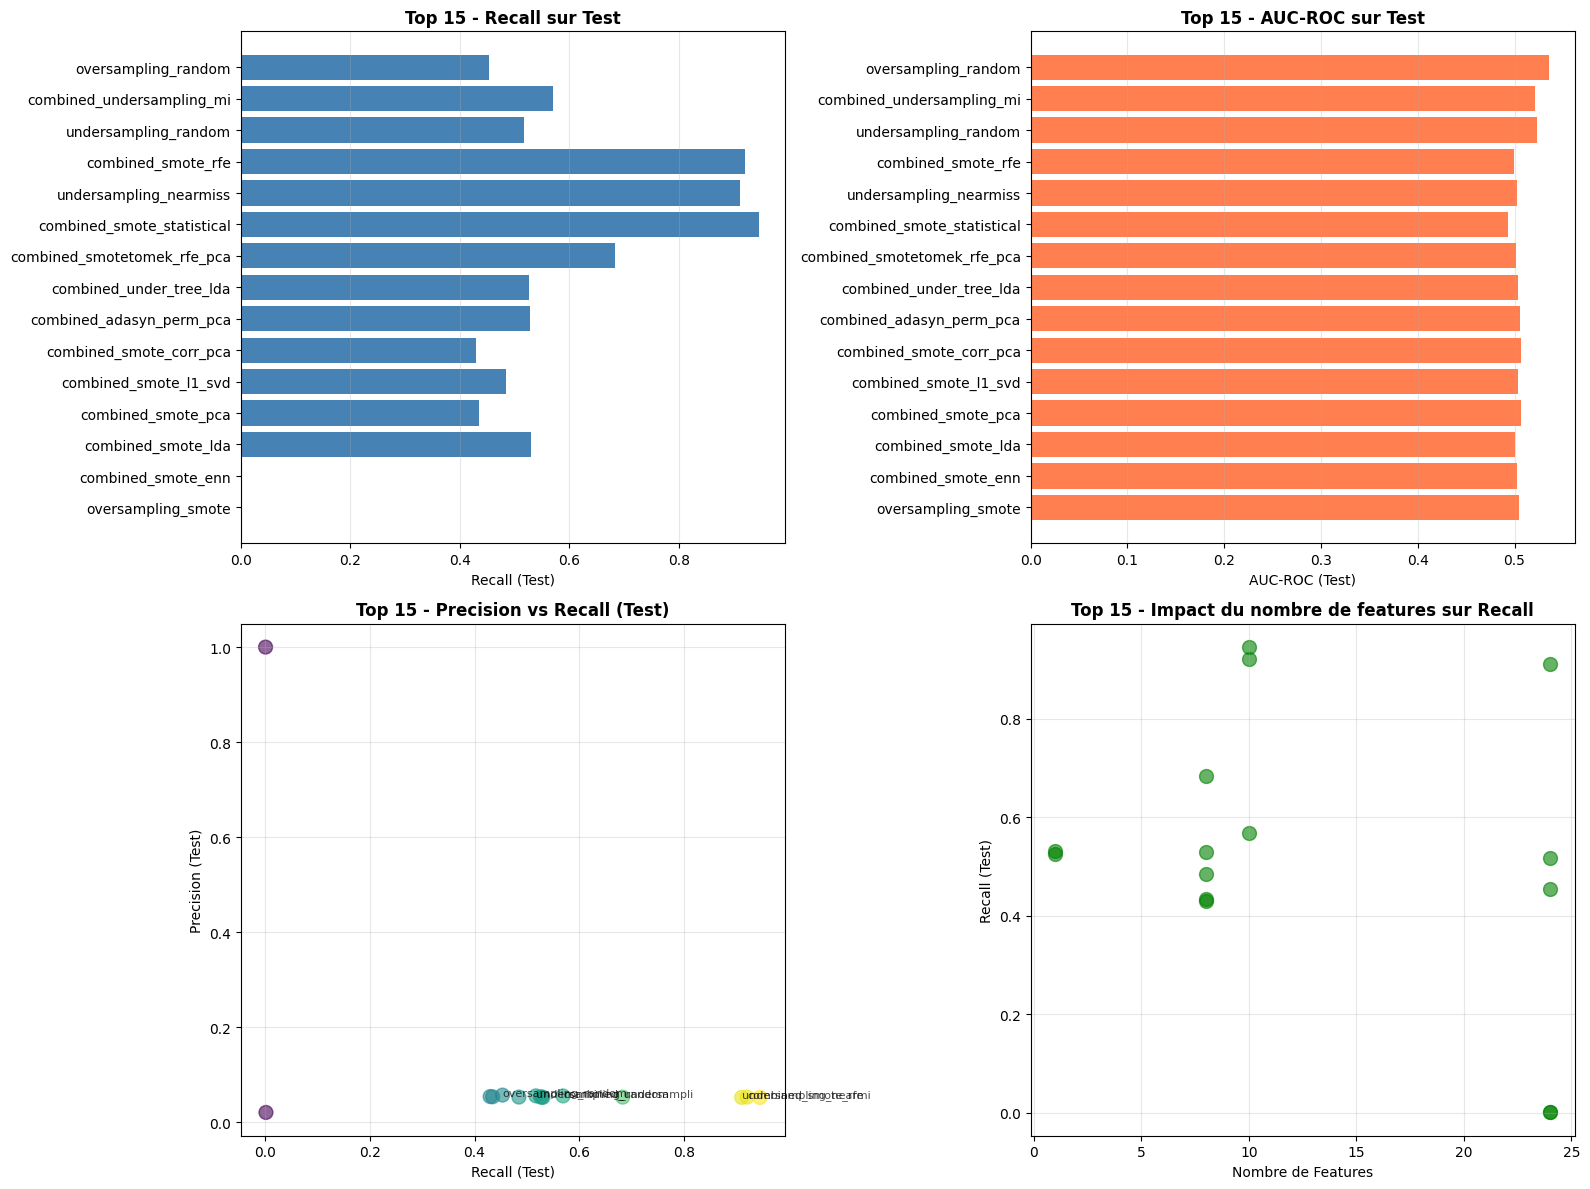


Graphiques sauvegardés: ../../data/data_variants/xgboost_evaluation_plots.png


In [62]:
# Visualisation des résultats (Top 15)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_n = 15
df_top = df_results.head(top_n)

# Recall Test
axes[0, 0].barh(df_top['variant'], df_top['test_rec'], color='steelblue')
axes[0, 0].set_xlabel('Recall (Test)')
axes[0, 0].set_title('Top 15 - Recall sur Test', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# AUC Test
axes[0, 1].barh(df_top['variant'], df_top['test_auc'], color='coral')
axes[0, 1].set_xlabel('AUC-ROC (Test)')
axes[0, 1].set_title('Top 15 - AUC-ROC sur Test', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Precision vs Recall Test
axes[1, 0].scatter(df_top['test_rec'], df_top['test_prec'], s=100, alpha=0.6, c=df_top['test_rec'], cmap='viridis')
axes[1, 0].set_xlabel('Recall (Test)')
axes[1, 0].set_ylabel('Precision (Test)')
axes[1, 0].set_title('Top 15 - Precision vs Recall (Test)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)
for i, row in df_top.head(5).iterrows():
    axes[1, 0].annotate(row['variant'][:20], (row['test_rec'], row['test_prec']), 
                        fontsize=8, alpha=0.7)

# Nombre de features vs Recall
axes[1, 1].scatter(df_top['n_features'], df_top['test_rec'], s=100, alpha=0.6, color='green')
axes[1, 1].set_xlabel('Nombre de Features')
axes[1, 1].set_ylabel('Recall (Test)')
axes[1, 1].set_title('Top 15 - Impact du nombre de features sur Recall', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'xgboost_evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGraphiques sauvegardés: {os.path.join(CONFIG['output_dir'], 'xgboost_evaluation_plots.png')}")

### 3.7. Save Best Variant to Dedicated Directory

We copy the best preprocessing variant to a dedicated directory (`best_data_dir`) for easy access by downstream notebooks (e.g., model training, XAI analysis).

This directory will contain:
- `X_train.parquet`, `X_val.parquet`, `X_test.parquet` (features)
- `y_train.parquet`, `y_val.parquet`, `y_test.parquet` (labels)

In [63]:
import shutil

# Define best data directory - CORRECTIF: doit être dans data/ directement
BEST_DATA_DIR = os.path.join('../../data', 'best_data')

# Create directory if it doesn't exist
os.makedirs(BEST_DATA_DIR, exist_ok=True)

print(f"\nCopying best variant to: {BEST_DATA_DIR}\n")

# Get best variant name
best_variant_name = best['variant']
best_variant_path = os.path.join(CONFIG['output_dir'], best_variant_name)

print(f"Best variant: {best_variant_name}")
print(f"Source: {best_variant_path}")

# CORRECTIF: Les fichiers sources sont train.parquet, val.parquet, test.parquet (pas X_train.parquet)
files_to_copy = [
    'train.parquet',
    'val.parquet', 
    'test.parquet'
]

# Copy each file
copied_files = []
for filename in files_to_copy:
    source_file = os.path.join(best_variant_path, filename)
    dest_file = os.path.join(BEST_DATA_DIR, filename)
    
    if os.path.exists(source_file):
        shutil.copy2(source_file, dest_file)
        file_size = os.path.getsize(dest_file) / (1024 * 1024)  # Size in MB
        copied_files.append(filename)
        print(f"{filename:20s} ({file_size:.2f} MB)")
    else:
        print(f"{filename:20s} NOT FOUND")

# Copy metadata as well
metadata_source = os.path.join(best_variant_path, 'metadata.json')
if os.path.exists(metadata_source):
    shutil.copy2(metadata_source, os.path.join(BEST_DATA_DIR, 'metadata.json'))
    copied_files.append('metadata.json')
    print(f"✓ metadata.json")

print(f"\n{len(copied_files)} fichiers copiés avec succès dans: {BEST_DATA_DIR}")

# Vérification finale
if len(copied_files) == 4:
    print("Copie réussie ! Le meilleur dataset est prêt à être utilisé.")
else:
    print("Certains fichiers sont manquants.")


Copying best variant to: ../../data\best_data

Best variant: oversampling_random
Source: ../../data/data_variants/oversampling_random
train.parquet        (91.20 MB)
val.parquet          (12.30 MB)
test.parquet         (12.30 MB)
✓ metadata.json

4 fichiers copiés avec succès dans: ../../data\best_data
Copie réussie ! Le meilleur dataset est prêt à être utilisé.
